# VisXAI: are the colors right?

Every other notebook in `examples/` answers *how* to produce a structure-mapped
explanation. This one asks whether the result is **correct**, which is normally
impossible: for almost any molecular property there is no per-atom reference to
check an atom-level explanation against.

Crippen's logP estimate is a useful exception. It is **defined** as a sum of
per-atom contributions, so RDKit can hand us ground truth at exactly the
granularity VisXAI produces. That turns "do these colors look plausible?" into a
question with a measurable answer.

Two pathways are put to the same test on the same target — a graph neural
network explained with Integrated Gradients, and a Morgan-fingerprint random
forest explained with TreeSHAP — because the interesting comparison is not just
*whether* attributions recover the reference, but whether the pathway that
predicts better also explains better.

Everything here runs offline: the molecules ship with RDKit.

In [1]:
import random

import numpy as np
import shap
import torch
from IPython.display import SVG, display
from rdkit import Chem, RDConfig, RDLogger
from rdkit.Chem import Crippen, rdMolDescriptors
from sklearn.ensemble import RandomForestRegressor
from torch_geometric.data import Batch
from torch_geometric.nn import global_add_pool

from visxai.core.data_types import Explanation
from visxai.explainers.gradient_based import IntegratedGradientsExplainer
from visxai.explainers.tree_shap import TreeSHAPExplainer
from visxai.features.fingerprints import generate_morgan_representation
from visxai.features.graphs import generate_graph_representation
from visxai.models.pytorch_wrapper import PyTorchGNNWrapper
from visxai.models.sklearn_wrapper import SklearnModelWrapper
from visxai.visualizers.rdkit_2d import RDKitSVGVisualizer

RDLogger.DisableLog("rdApp.*")

## The dataset

RDKit ships a set of NCI compounds, so no external download or committed data
file is needed. We keep neutral molecules of 6-30 heavy atoms built from common
organic elements — enough variety for a real regression, small enough that the
whole notebook runs in seconds.

In [2]:
import os

ALLOWED_ELEMENTS = {6, 7, 8, 9, 15, 16, 17, 35, 53}


def load_molecules(limit=900):
    """Neutral, mid-sized, common-element molecules from RDKit's own data."""
    path = os.path.join(RDConfig.RDDataDir, "NCI", "first_5K.smi")
    kept = []
    with open(path) as handle:
        for line in handle:
            mol = Chem.MolFromSmiles(line.split()[0].strip())
            if mol is None or not (6 <= mol.GetNumAtoms() <= 30):
                continue
            if any(a.GetAtomicNum() not in ALLOWED_ELEMENTS for a in mol.GetAtoms()):
                continue
            if any(a.GetFormalCharge() != 0 for a in mol.GetAtoms()):
                continue
            kept.append(Chem.MolToSmiles(mol))
            if len(kept) >= limit:
                break
    return kept


smiles_list = load_molecules()
print(f"molecules: {len(smiles_list)}")
print("first three:", smiles_list[:3])

molecules: 900
first three: ['CC1=CC(=O)C=CC1=O', 'c1ccc2sc(SSc3nc4ccccc4s3)nc2c1', 'Nc1ccc2c(c1)C(=O)c1ccccc1C2=O']


## The ground truth, and one trap in obtaining it

`rdMolDescriptors._CalcCrippenContribs(mol)` returns one contribution per atom
*of the molecule it is given*. The published `MolLogP` value, however, is the
sum over the **hydrogen-explicit** molecule — hydrogens carry their own
contributions.

So calling it on a normal (implicit-hydrogen) molecule and summing does **not**
reproduce `MolLogP`; on this dataset it is off by up to 6.9 log units, and the
discrepancy is systematically signed rather than random. Comparing attributions
against that quantity would understate agreement badly — an early version of
this notebook measured a correlation of 0.37 for exactly this reason.

The fix is to fold each hydrogen's contribution onto the heavy atom it is
attached to, which is also the right thing conceptually: VisXAI scores heavy
atoms, and a heavy atom's chemistry includes its hydrogens.

In [3]:
def crippen_per_heavy_atom(mol):
    """Crippen logP per heavy atom, hydrogens folded onto their heavy atom."""
    mol_h = Chem.AddHs(mol)
    contributions = [c[0] for c in rdMolDescriptors._CalcCrippenContribs(mol_h)]
    per_heavy = np.zeros(mol.GetNumAtoms())
    for atom in mol_h.GetAtoms():
        if atom.GetAtomicNum() == 1:
            per_heavy[atom.GetNeighbors()[0].GetIdx()] += contributions[atom.GetIdx()]
        else:
            per_heavy[atom.GetIdx()] += contributions[atom.GetIdx()]
    return per_heavy


molecules = [Chem.MolFromSmiles(s) for s in smiles_list]
reference = [crippen_per_heavy_atom(m) for m in molecules]
targets = [float(Crippen.MolLogP(m)) for m in molecules]

folded_error = max(abs(r.sum() - t) for r, t in zip(reference, targets))
naive_error = max(
    abs(sum(c[0] for c in rdMolDescriptors._CalcCrippenContribs(m)) - t)
    for m, t in zip(molecules, targets)
)
print(f"max |sum(reference) - MolLogP|, hydrogens folded in : {folded_error:.2e}")
print(f"max |sum(reference) - MolLogP|, hydrogens ignored   : {naive_error:.2f}")
print("\nThe first is exact to numerical noise -- that is our ground truth.")

max |sum(reference) - MolLogP|, hydrogens folded in : 9.77e-15
max |sum(reference) - MolLogP|, hydrogens ignored   : 6.92

The first is exact to numerical noise -- that is our ground truth.


## Pathway 1: a graph neural network

The target is a *sum* over atoms, so the readout pools by summation rather than
averaging — this lets the network represent the additive structure it is being
asked to learn. Note that the featurizer never sees a logP-derived quantity;
it only reports elementary atom properties.

In [4]:
def atom_featurizer(atom):
    return [
        float(atom.GetAtomicNum()),
        float(atom.GetDegree()),
        float(atom.GetTotalNumHs()),
        float(atom.GetIsAromatic()),
        float(atom.IsInRing()),
    ]


def bond_featurizer(bond):
    return [float(bond.GetBondTypeAsDouble())]


class LogPGNN(torch.nn.Module):
    """2-layer message passing with SUM pooling, matching an additive target."""

    def __init__(self, in_dim=5, edge_dim=1, hidden=32, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.msg1 = torch.nn.Linear(in_dim + edge_dim, hidden)
        self.self1 = torch.nn.Linear(in_dim, hidden)
        self.msg2 = torch.nn.Linear(hidden + edge_dim, hidden)
        self.self2 = torch.nn.Linear(hidden, hidden)
        self.out = torch.nn.Linear(hidden, 1)

    @staticmethod
    def _layer(x, edge_index, edge_attr, msg_lin, self_lin):
        src, dst = edge_index[0], edge_index[1]
        messages = msg_lin(torch.cat([x[src], edge_attr], dim=-1)).relu()
        agg = torch.zeros(x.shape[0], messages.shape[-1], dtype=messages.dtype)
        agg = agg.index_add(0, dst, messages)
        return (self_lin(x) + agg).relu()

    def forward(self, x, edge_index, edge_attr, batch):
        h = self._layer(x, edge_index, edge_attr, self.msg1, self.self1)
        h = self._layer(h, edge_index, edge_attr, self.msg2, self.self2)
        return global_add_pool(self.out(h), batch)


graph_reps = [
    generate_graph_representation(s, atom_featurizer, bond_featurizer)
    for s in smiles_list
]

rng = random.Random(0)
order = list(range(len(smiles_list)))
rng.shuffle(order)
split = int(0.8 * len(order))
train_idx, test_idx = order[:split], order[split:]
print(f"train {len(train_idx)} / test {len(test_idx)}")

train 720 / test 180


In [5]:
train_batch = Batch.from_data_list([graph_reps[i].pyg_data for i in train_idx])
y_train = torch.tensor([[targets[i]] for i in train_idx], dtype=torch.float)

gnn = LogPGNN()
optimizer = torch.optim.Adam(gnn.parameters(), lr=5e-3)
loss_fn = torch.nn.MSELoss()

gnn.train()
for epoch in range(400):
    optimizer.zero_grad()
    out = gnn(train_batch.x, train_batch.edge_index, train_batch.edge_attr, train_batch.batch)
    loss = loss_fn(out, y_train)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"  epoch {epoch:3d}  train MSE {loss.item():.4f}")
gnn.eval()

test_batch = Batch.from_data_list([graph_reps[i].pyg_data for i in test_idx])
y_test = torch.tensor([[targets[i]] for i in test_idx], dtype=torch.float)
with torch.no_grad():
    pred = gnn(test_batch.x, test_batch.edge_index, test_batch.edge_attr, test_batch.batch)
gnn_r2 = 1 - ((pred - y_test) ** 2).sum().item() / ((y_test - y_test.mean()) ** 2).sum().item()
print(f"\ngraph model test R^2 = {gnn_r2:.3f}")

  epoch   0  train MSE 43.3933
  epoch 100  train MSE 0.7601
  epoch 200  train MSE 0.5655
  epoch 300  train MSE 0.3954

graph model test R^2 = 0.890


### Comparing Integrated Gradients against the reference

Two correlations are reported per molecule and they answer different questions.
Pearson asks whether the attributed *values* track the reference; Spearman asks
only whether the atoms are put in the same *order*, which is closer to what a
reader actually takes from a colored figure.

In [6]:
def average_ranks(values):
    """Ranks with ties averaged. Spearman's rho is Pearson's r on these."""
    order_ = sorted(range(len(values)), key=lambda i: values[i])
    ranks = [0.0] * len(values)
    start = 0
    while start < len(order_):
        stop = start
        while stop + 1 < len(order_) and values[order_[stop + 1]] == values[order_[start]]:
            stop += 1
        for position in range(start, stop + 1):
            ranks[order_[position]] = (start + stop) / 2.0
        start = stop + 1
    return ranks


def agreement_with_reference(scores, truth):
    """Pearson and Spearman between one molecule's scores and the reference."""
    if np.std(scores) < 1e-12 or np.std(truth) < 1e-12:
        return None
    pearson = float(np.corrcoef(scores, truth)[0, 1])
    spearman = float(np.corrcoef(average_ranks(list(scores)), average_ranks(list(truth)))[0, 1])
    return pearson, spearman


EXPLAIN_N = 150
explained_idx = test_idx[:EXPLAIN_N]

gnn_wrapper = PyTorchGNNWrapper(gnn, uses_edge_attr=True)
ig_explainer = IntegratedGradientsExplainer(n_steps=64)

gnn_explanations, gnn_pearson, gnn_spearman = {}, [], []
for i in explained_idx:
    exp = ig_explainer.explain(gnn_wrapper, graph_reps[i])
    gnn_explanations[i] = exp
    scores = [exp.atom_scores[j] for j in range(molecules[i].GetNumAtoms())]
    scored = agreement_with_reference(scores, reference[i])
    if scored:
        gnn_pearson.append(scored[0])
        gnn_spearman.append(scored[1])

print(f"graph + Integrated Gradients, over {len(gnn_pearson)} molecules")
print(f"  Pearson  vs reference: median {np.median(gnn_pearson):+.3f}  mean {np.mean(gnn_pearson):+.3f}")
print(f"  Spearman vs reference: median {np.median(gnn_spearman):+.3f}  mean {np.mean(gnn_spearman):+.3f}")

graph + Integrated Gradients, over 150 molecules
  Pearson  vs reference: median +0.634  mean +0.550
  Spearman vs reference: median +0.517  mean +0.494


## Pathway 2: a fingerprint random forest

### First, a caution that changes how the model must be trained

TreeSHAP's guarantee is that the attributed values sum to the model's output.
On this dataset that guarantee **silently stops holding once the trees get very
deep**, which is easy to trigger since an unconstrained forest on a few hundred
molecules grows to depth 70 or more.

The cell below measures it directly. This is a limitation of the underlying
`shap` implementation rather than of VisXAI, and it is worth knowing about
because the failure is quantitative, not a crash: at moderate depth the error
is invisible, and by depth 75 the "explanation" bears no relation to the
prediction.

`TreeSHAPExplainer` does not paper over this — `shap` checks additivity by
default, so `explain()` raises rather than returning corrupt scores. The
message it raises blames the shape of the input matrix, which is misleading, so
recognising the real cause is useful.

In [7]:
fp_reps = [generate_morgan_representation(s, n_bits=2048) for s in smiles_list]
X_train = np.array([fp_reps[i].fingerprint_array for i in train_idx])
y_fp_train = np.array([targets[i] for i in train_idx])

print(f"{'max_depth':>10} {'actual depth':>13} {'worst additivity error':>24}")
for max_depth in (8, 12, None):
    probe = RandomForestRegressor(
        n_estimators=50, max_depth=max_depth, random_state=42
    ).fit(X_train, y_fp_train)
    explainer = shap.TreeExplainer(probe)
    base = float(np.ravel(explainer.expected_value)[0])
    worst = 0.0
    for i in test_idx[:20]:
        row = fp_reps[i].fingerprint_array.reshape(1, -1)
        # check_additivity=False so we can MEASURE the error instead of raising.
        values = np.asarray(explainer.shap_values(row, check_additivity=False))
        worst = max(worst, abs(base + values.ravel().sum() - float(probe.predict(row)[0])))
    depth = max(est.get_depth() for est in probe.estimators_)
    print(f"{str(max_depth):>10} {depth:>13} {worst:>24.4f}")

 max_depth  actual depth   worst additivity error
         8             8                   0.0000
        12            12                   0.0000
      None            75                  15.6806


### The model, with depth constrained

Capping depth is not hyperparameter tuning here — it is what makes the
attributions mean anything. It costs accuracy, and that cost is part of the
comparison rather than something to hide.

In [8]:
forest = RandomForestRegressor(
    n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
).fit(X_train, y_fp_train)

X_test = np.array([fp_reps[i].fingerprint_array for i in test_idx])
y_fp_test = np.array([targets[i] for i in test_idx])
fp_pred = forest.predict(X_test)
fp_r2 = 1 - ((fp_pred - y_fp_test) ** 2).sum() / ((y_fp_test - y_fp_test.mean()) ** 2).sum()
print(f"fingerprint model test R^2 = {fp_r2:.3f}")

fp_wrapper = SklearnModelWrapper(forest)
tree_explainer = TreeSHAPExplainer()

fp_explanations, fp_pearson, fp_spearman = {}, [], []
for i in explained_idx:
    exp = tree_explainer.explain(fp_wrapper, fp_reps[i])
    fp_explanations[i] = exp
    scores = [exp.atom_scores[j] for j in range(molecules[i].GetNumAtoms())]
    scored = agreement_with_reference(scores, reference[i])
    if scored:
        fp_pearson.append(scored[0])
        fp_spearman.append(scored[1])

print(f"\nfingerprint + TreeSHAP, over {len(fp_pearson)} molecules")
print(f"  Pearson  vs reference: median {np.median(fp_pearson):+.3f}  mean {np.mean(fp_pearson):+.3f}")
print(f"  Spearman vs reference: median {np.median(fp_spearman):+.3f}  mean {np.mean(fp_spearman):+.3f}")

fingerprint model test R^2 = 0.578

fingerprint + TreeSHAP, over 150 molecules
  Pearson  vs reference: median +0.530  mean +0.457
  Spearman vs reference: median +0.545  mean +0.483


## What the two pathways say together

In [9]:
print(f"{'pathway':<28} {'test R^2':>9} {'Pearson':>9} {'Spearman':>9}")
print("-" * 58)
print(f"{'graph + IG':<28} {gnn_r2:>9.3f} {np.median(gnn_pearson):>9.3f} {np.median(gnn_spearman):>9.3f}")
print(f"{'Morgan + TreeSHAP':<28} {fp_r2:>9.3f} {np.median(fp_pearson):>9.3f} {np.median(fp_spearman):>9.3f}")
print("\n(correlations are per-molecule medians against the Crippen reference)")

print(f"\naccuracy gap : {gnn_r2 - fp_r2:+.3f} R^2 in favour of the graph model")
print(f"ordering gap : {np.median(gnn_spearman) - np.median(fp_spearman):+.3f} Spearman")

pathway                       test R^2   Pearson  Spearman
----------------------------------------------------------
graph + IG                       0.890     0.634     0.517
Morgan + TreeSHAP                0.578     0.530     0.545

(correlations are per-molecule medians against the Crippen reference)

accuracy gap : +0.312 R^2 in favour of the graph model
ordering gap : -0.028 Spearman


Two conclusions, both worth stating plainly.

**The reference is recovered only partially.** A rank agreement near 0.5 means
the attributions are informative about which atoms push the prediction up or
down, but they are not a decomposition that can be read atom by atom — and this
is the friendly case, where the property is *exactly* additive and the model
fits it well. Explanations of this kind support exploration; they do not
license quantitative per-atom claims.

**Predicting better does not mean explaining better.** The graph model wins on
accuracy by a wide margin, yet the two pathways order the atoms about equally
well. Faithfulness and accuracy are separate properties that have to be
measured separately — and being able to measure them side by side, in shared
atom coordinates, is the reason for a toolkit that spans representations
instead of one per model family.

## Seeing it, rather than reading correlations

The reference decomposition is just a number per atom, which is exactly what an
`Explanation` holds — so it can be handed to the ordinary visualizer and drawn
with the same code path as any model explanation. Below, the same molecule is
rendered three times: ground truth, then each pathway's attempt at it.

Colors are normalized per figure, so this compares *patterns*, not magnitudes
(the three quantities are in different units).

molecule: CCCCC(O)(CCCC)C(C)(C)C
atoms:    14

-- Crippen reference (ground truth) --


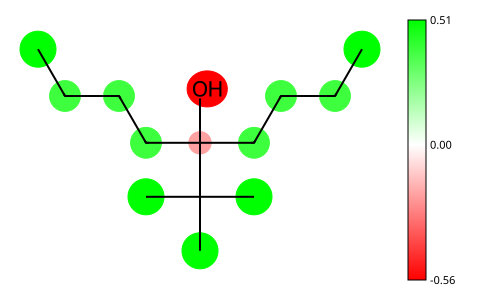


-- graph + Integrated Gradients --


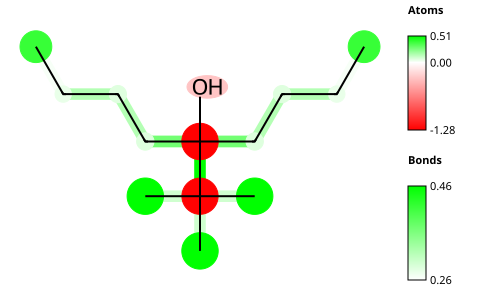


-- Morgan + TreeSHAP --


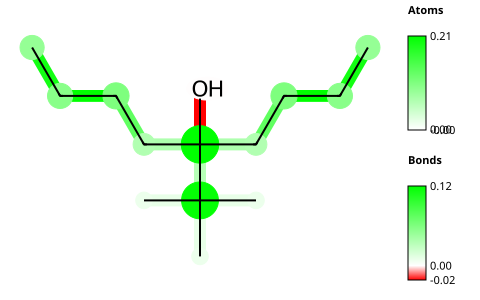

In [10]:
# Pick a mid-sized molecule the graph pathway did reasonably well on.
candidates = sorted(
    (i for i in explained_idx if 12 <= molecules[i].GetNumAtoms() <= 18),
    key=lambda i: -agreement_with_reference(
        [gnn_explanations[i].atom_scores[j] for j in range(molecules[i].GetNumAtoms())],
        reference[i],
    )[1],
)
chosen = candidates[0]
print("molecule:", smiles_list[chosen])
print("atoms:   ", molecules[chosen].GetNumAtoms())

truth_explanation = Explanation(
    atom_scores={j: float(reference[chosen][j]) for j in range(molecules[chosen].GetNumAtoms())},
    metadata={"attribution": "reference/crippen"},
)

visualizer = RDKitSVGVisualizer(legend_units="raw")
for label, rep, exp in (
    ("Crippen reference (ground truth)", graph_reps[chosen], truth_explanation),
    ("graph + Integrated Gradients", graph_reps[chosen], gnn_explanations[chosen]),
    ("Morgan + TreeSHAP", fp_reps[chosen], fp_explanations[chosen]),
):
    print(f"\n-- {label} --")
    display(SVG(visualizer.visualize(rep, exp)))

## Exploring the disagreement interactively

The correlations above are summary statistics, and a median hides the thing
worth looking at: agreement is not uniform. Some molecules are recovered
almost exactly and some are recovered backwards, and the static figure above
shows only one of them.

`ExplanationDashboard` is a better instrument for this. It compares
**pre-computed** explanations on a molecule/method grid and never re-runs an
explainer, so the panels below cost nothing beyond the work already done. The
grid here is unusual and useful: one axis is the molecule, and the other holds
two attribution methods **plus the ground truth**, which can sit alongside them
because a reference expressed per atom is the same kind of object as a model
explanation.

Three molecules are registered, chosen by how well the graph pathway recovered
the reference: its best case, its median case, and its worst. Reading the best
against the worst is the honest version of the summary statistic.

One note on the colour scale. The three panels are in **different units** —
logP contributions, Integrated Gradients attributions, and SHAP values — so
pooling them into a shared range would be meaningless. Per-panel normalization
is correct here, and it is what the dashboard defaults to when the legend
reports normalized units. The comparison to make is of *pattern*, not
magnitude.

In [11]:
from visxai.visualizers.interactive import ExplanationDashboard

# Rank the explained molecules by how well the graph pathway recovered the
# reference, then take the best, median and worst -- the spread is the point.
ranked = sorted(
    (
        (
            agreement_with_reference(
                [gnn_explanations[i].atom_scores[j] for j in range(molecules[i].GetNumAtoms())],
                reference[i],
            )[1],
            i,
        )
        for i in explained_idx
        if agreement_with_reference(
            [gnn_explanations[i].atom_scores[j] for j in range(molecules[i].GetNumAtoms())],
            reference[i],
        )
    ),
    reverse=True,
)
picks = [("best", ranked[0]), ("median", ranked[len(ranked) // 2]), ("worst", ranked[-1])]

results = {}
for label, (rho, i) in picks:
    n_atoms_i = molecules[i].GetNumAtoms()
    truth = Explanation(
        atom_scores={j: float(reference[i][j]) for j in range(n_atoms_i)},
        metadata={"attribution": "reference/crippen"},
    )
    # mol_rep is a property of the molecule, not of the explanation, so one
    # representation carries all three -- the atom indices are identical
    # because both were built from the same SMILES.
    results[f"{label} (rho {rho:+.2f})"] = (
        fp_reps[i],
        {
            "Crippen reference": truth,
            "graph + IG": gnn_explanations[i],
            "Morgan + TreeSHAP": fp_explanations[i],
        },
    )
    print(f"{label:>6}: rho {rho:+.2f}  {n_atoms_i:2d} atoms  {smiles_list[i]}")

dashboard = ExplanationDashboard.from_results(results, n_panels=3, width=340, height=280)
print("\nmolecules: ", dashboard.molecules)
print("explainers:", dashboard.explainers)

  best: rho +1.00  10 atoms  CC(C)(C)OOC(C)(C)C
median: rho +0.52  14 atoms  CCCC(=O)c1cc(C)ccc1OC
 worst: rho -0.71  13 atoms  O=S(=O)(O)N(S(=O)(=O)O)S(=O)(=O)O

molecules:  ['best (rho +1.00)', 'median (rho +0.52)', 'worst (rho -0.71)']
explainers: ['Crippen reference', 'graph + IG', 'Morgan + TreeSHAP']


### What to look for

Set all three panels to the same molecule and step the *explainer* selector
through reference, graph and fingerprint. On the best-agreement molecule the
three colour patterns broadly track one another; on the worst they do not, and
seeing which atoms flip is far more informative than the correlation that
summarised it.

The hover readout also distinguishes the three panels in a way the colours
cannot. Hovering an atom gives its raw score, the normalized value driving the
colour, and how that score was assembled — and the last part differs by
pathway. The fingerprint panel itemises the bits that contributed and how far
each was divided; the graph panel has nothing to itemise, because node *i* is
atom *i*; and the reference panel is a plain per-atom quantity that was never
mapped at all.

In [12]:
dashboard.display()

In [13]:
# Sanity check, so this section is verifiable without a browser.
#
# nbclient executes `display(widget)` happily whether or not anything actually
# renders, so executing the notebook proves very little on its own. These
# asserts use only the public API -- render_svg() returns the same SVG a panel
# shows, independent of the widget tree.
import re

rendered = {
    (mol, exp): dashboard.render_svg(mol, exp)
    for mol in dashboard.molecules
    for exp in dashboard.explainers
    if dashboard.render_svg(mol, exp) is not None
}
assert rendered, "no registered pair rendered"
for (mol, exp), svg in rendered.items():
    assert "<svg" in svg, (mol, exp)

print(f"rendered {len(rendered)} panel(s) across {len(dashboard.molecules)} molecule(s) "
      f"x {len(dashboard.explainers)} explainer(s)")

# The ground truth really did go through the same rendering path as the models.
assert dashboard.render_svg(dashboard.molecules[0], "Crippen reference") is not None
print("the Crippen reference renders through the ordinary visualizer, "
      "like any model explanation")

rendered 9 panel(s) across 3 molecule(s) x 3 explainer(s)
the Crippen reference renders through the ordinary visualizer, like any model explanation


## Next steps

- `tree_demo.ipynb` and `graph_demo.ipynb` ask the companion question — how much
  an explanation depends on the *feature scheme* rather than the chemistry —
  and reach opposite answers for fingerprints and graph featurizers. Both close
  with their own interactive section.
- `dashboard_demo.ipynb` covers the interactive layer on its own terms: the
  scale modes, the hover-linked SMILES strip, and how a widget notebook can
  still be verified without a browser.